In [2]:
# Стандартна бібліотека
import os
import sys
import time
import itertools
import json
import random
from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict, Counter
from typing import Any, Dict, List, Optional, Tuple

# Наукові обчислення та табличні дані
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Візуалізація
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap

# Комп'ютерний зір та зображення
import cv2
from PIL import Image
from IPython.display import display

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils import clip_grad_norm_
from torch.cuda.amp import autocast, GradScaler

# TorchVision
import torchvision
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    maskrcnn_resnet50_fpn,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models import ResNet50_Weights
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from torchvision.ops import nms, box_iou
from torchvision.ops import roi_align as _roi_align
from pycocotools import mask as maskUtils
from pycocotools.coco import COCO

# Класифікатори
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Аугментації
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Перевірка CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"torch current device: {torch.cuda.current_device()}")
print(f"Training device: {device}")


PyTorch version: 2.8.0+cu129
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA version: 12.9
torch current device: 0
Training device: cuda


In [2]:
@dataclass
class Config:
    coco_root: str = '../coco2017'
    train_root: str = os.path.join(coco_root, 'train2017')
    val_root: str = os.path.join(coco_root, 'val2017')
    train_ann: str = os.path.join(coco_root, 'annotations', 'instances_train2017.json')
    val_ann: str = os.path.join(coco_root, 'annotations', 'instances_val2017.json')

    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    seed: int = 42
    checkpoint_dir: str = './checkpoints'
    save_every: int = 5  # epochs

cfg = Config()
print("\n" + "="*80)
print("КОНФІГУРАЦІЯ ПРОЕКТУ")
print("="*80)
print(f"Dataset: COCO 2017")
print(f"Device: {cfg.device}")
print(f"Checkpoint dir: {cfg.checkpoint_dir}")
print("="*80 + "\n")


КОНФІГУРАЦІЯ ПРОЕКТУ
Dataset: COCO 2017
Device: cuda
Checkpoint dir: ./checkpoints



## 3(б)/4(б)/5(б). Реалізовані архітектури

- **FCN-32s (4б)**: базується на **AlexNet features** як енкодері та 1×1-класифікаторі з білінійним upsample до розміру вхідного зображення.
  *Код:* `class FCN32s`.

- **Mask R-CNN (5б)**: взято `maskrcnn_resnet50_fpn` з torchvision; box/mask-голови переналаштовані під число класів датасету (top-K).
  *Код/ініціалізація:* `get_maskrcnn(...)`.

> Для економії часу/ресурсів сегментацію обмежено top-K класами COCO (див. датасети нижче).


In [9]:


class FCN32s(nn.Module):
    def __init__(self, num_classes: int = 21, pretrained_backbone: bool = True, freeze_encoder: bool = False):
        super().__init__()
        alex = torchvision.models.alexnet(
            weights=torchvision.models.AlexNet_Weights.IMAGENET1K_V1 if pretrained_backbone else None
        )

        self.encoder = alex.features

        self.enc_out_channels = 256 if not hasattr(self.encoder[-1], "out_channels") else self.encoder[-1].out_channels
        self.score = nn.Conv2d(self.enc_out_channels, num_classes, kernel_size=1)

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        H, W = x.shape[-2:]
        feat = self.encoder(x)
        score = self.score(feat)
        out = F.interpolate(score, size=(H, W), mode='bilinear', align_corners=False)
        return out


In [10]:


def get_maskrcnn(
    num_classes: int,
    pretrained_backbone: bool = True,
    pretrained_weights: bool = True,
    box_score_thresh: float | None = None,
    batch_size_per_image: int | None = None,
):
    """
    Повертає Mask R-CNN (ResNet50-FPN) з оновленим API weights/weights_backbone
    та підміненою box/mask головами під num_classes.
    """
    if pretrained_weights:
        model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    else:
        model = maskrcnn_resnet50_fpn(
            weights=None,
            weights_backbone=(ResNet50_Weights.IMAGENET1K_V1 if pretrained_backbone else None),
        )


    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, num_classes
    )


    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )


    if box_score_thresh is not None and hasattr(model.roi_heads, "score_thresh"):
        model.roi_heads.score_thresh = float(box_score_thresh)
    if batch_size_per_image is not None:
        model.roi_heads.batch_size_per_image = int(batch_size_per_image)

    return model


In [11]:

DEFAULTS_MINI = {
    "train": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 2,
        "epochs": 10,
        "scheduler": "none",
        "grad_clip": None,
        "seed": 42,

        "momentum": 0.9,
        "nesterov": True,
    },
    "aug": {
        "hflip_p": 0.5,
    }
}


SEARCH_SPACE_MINI = {
    "train": {
        "learning_rate": [1e-3, 3e-4],
        "batch_size":    [4, 8],
        "weight_decay":  [0.0, 1e-4],
        "scheduler":     ["none", "StepLR_5_0.5"],
    },

    "alexnet_detector": {
        "anchor_scales": [(32, 64, 128)],
        "anchor_ratios": [(0.5, 1.0, 2.0)],
        "rpn_nms_thresh": [0.7],
        "roi_size":       [7],
    },
    "rcnn": {
        "roi_size":        [7],
        "freeze_backbone": [True, False],
    },
    "tiny_yolo": {
        "S":           [7],
        "B":           [1, 2],
        "image_size":  [224],
        "conf_thresh": [0.25, 0.4],
    },

    "fcn32s": {
        "upsample_scale": [32],
        "loss_type":      ["CE"],    #
    },
    "mask_rcnn": {
        "box_score_thresh":     [0.5],
        "batch_size_per_image": [256],
    }
}


import copy, re, torch
from torch.optim import Adam, AdamW, SGD
from torch.optim.lr_scheduler import StepLR

def set_seed(seed: int = 42):
    import os, random, numpy as np
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def hp_compose(model_key: str, overrides: dict | None = None):
    """
    Беремо DEFAULTS_MINI + перші значення з SEARCH_SPACE_MINI[model_key].
    overrides (необов’язково): {"train": {...}, model_key: {...}}
    """
    hp = copy.deepcopy(DEFAULTS_MINI)
    if model_key in SEARCH_SPACE_MINI:
        hp[model_key] = {
            k: (v[0] if isinstance(v, list) else v)
            for k, v in SEARCH_SPACE_MINI[model_key].items()
        }
    if overrides:
        if "train" in overrides:
            hp["train"].update(overrides["train"])
        if model_key in overrides:
            hp[model_key].update(overrides[model_key])
    set_seed(hp["train"]["seed"])
    return hp

def build_optimizer(model: torch.nn.Module, hp: dict):
    t = hp["train"]
    name = str(t.get("optimizer", "Adam")).lower()
    if name == "adam":
        return Adam(model.parameters(), lr=t["learning_rate"], weight_decay=t["weight_decay"])
    if name == "adamw":
        return AdamW(model.parameters(), lr=t["learning_rate"], weight_decay=t["weight_decay"])
    if name == "sgd":
        return SGD(
            model.parameters(),
            lr=t["learning_rate"],
            momentum=float(t.get("momentum", 0.9)),
            nesterov=bool(t.get("nesterov", True)),
            weight_decay=t["weight_decay"],
        )
    raise ValueError(f"Unknown optimizer: {t['optimizer']}")

def build_scheduler(optimizer, hp: dict):
    sch = str(hp["train"].get("scheduler", "none")).lower()
    if sch.startswith("steplr_"):

        m = re.match(r"steplr_(\d+)_([0-9]*\.?[0-9]+)", sch)
        step_size = int(m.group(1)) if m else 5
        gamma = float(m.group(2)) if m else 0.5
        return StepLR(optimizer, step_size=step_size, gamma=gamma)
    return None


## 6. Гіперпараметри

### Спільні (тренування)
- `optimizer ∈ {Adam, AdamW, SGD}` — метод оптимізації.
- `learning_rate ∈ {1e-3, 3e-4}` — базова швидкість навчання.
- `weight_decay ∈ {0.0, 1e-4}` — L2-регуляризація.
- `batch_size ∈ {2, 4, 8}` — кількість зображень у батчі.
- `epochs` — кількість епох.
- `scheduler ∈ {none, StepLR_5_0.5}` — планувальник LR.
- `grad_clip` — обрізання градієнтів (опційно).

### FCN-32s
- `upsample_scale=32` — масштаб підйому в FCN-голові.
- `loss_type='CE'` — `CrossEntropyLoss`.

### Mask R-CNN
- `box_score_thresh=0.5` — поріг відсікання предиктів.
- `batch_size_per_image=256` — скільки ROI семплити на зображення.

> Усі діапазони/дефолти зафіксовані в `DEFAULTS_MINI` та `SEARCH_SPACE_MINI`.


## 7. Підбір гіперпараметрів (tuning)

**Підхід:** сітковий перебір малих підпросторів (`learning_rate`, `batch_size`, `weight_decay`, `scheduler`) з проксі-кроком `_proxy_step` (для швидкої оцінки), та підмножин специфічних параметрів моделі.

**Оцінка впливу:** після запуску `tune_hparams(...)` формується таблиця з `metric` і обчислюється **дельта-важливість** гіперпараметрів (різниця між середнім найкращим та найгіршим значенням по кожному параметру).
Результати візуалізую барчартом (див. блок побудови `importance_delta`).

**Що саме тюниться тут:**
- Загальні: `learning_rate`, `batch_size`, `weight_decay`, `scheduler`.
- Специфічні: для `mask_rcnn` — `box_score_thresh`, `batch_size_per_image`; для `fcn32s` — `upsample_scale` (зафіксовано 32) і тип лосу (CE).

> Фінальні найкращі гіперпараметри зберігаю через `summarize_run(..., save_json_path=...)`.


In [12]:


def _make_grid(space: dict):
    """Перетворює словник space у декартів добуток значень."""
    if not space:
        return [dict()]
    keys = list(space.keys())
    vals = [v if isinstance(v, list) else [v] for v in (space[k] for k in keys)]
    return [dict(zip(keys, combo)) for combo in itertools.product(*vals)]

def _tensor_mean_abs(x):
    """Акуратно згортає будь-яку структуру до тензорної скалярної «втрати»."""
    if torch.is_tensor(x):
        return x.float().abs().mean()
    if isinstance(x, dict):
        parts = [v for v in x.values() if torch.is_tensor(v)]
        if parts:
            return torch.stack([p.float().abs().mean() for p in parts]).mean()
        return torch.tensor(0.0, device=cfg.device)
    if isinstance(x, (list, tuple)):
        parts = [p for p in x if torch.is_tensor(p)]
        if parts:
            return torch.stack([p.float().abs().mean() for p in parts]).mean()

        vals = [_tensor_mean_abs(p) for p in x]
        return torch.stack(vals).mean() if vals else torch.tensor(0.0, device=cfg.device)
    return torch.tensor(0.0, device=cfg.device)

def _proxy_step(model, optimizer, scheduler, hp, model_key: str):
    """Один міні-крок 'навчання' + проксі-метрика (–loss). Замінюй на реальний train/eval."""
    bs = hp["train"]["batch_size"]
    img_size = 224 if model_key != "tiny_yolo" else hp.get(model_key, {}).get("image_size", 224)
    xb = torch.randn(bs, 3, img_size, img_size, device=cfg.device)

    model.train()
    optimizer.zero_grad(set_to_none=True)


    out = None
    try:
        out = model(xb)
    except Exception:
        out = None

    loss = None
    if out is not None:
        loss = _tensor_mean_abs(out)

        if not getattr(loss, "requires_grad", False):
            out = model.backbone(xb) if hasattr(model, "backbone") else xb
            loss = _tensor_mean_abs(out)
    else:

        out = model.backbone(xb) if hasattr(model, "backbone") else xb
        loss = _tensor_mean_abs(out)

    loss.backward()
    if hp["train"].get("grad_clip"):
        torch.nn.utils.clip_grad_norm_(model.parameters(), hp["train"]["grad_clip"])
    optimizer.step()
    if scheduler:
        scheduler.step()

    metric = float(-loss.item())
    return metric

def tune_hparams(model_key: str, model_factory,
                 train_space: dict | None = None,
                 model_space: dict | None = None,
                 max_trials: int | None = None,
                 repeats: int = 1):
    """
    model_key: "alexnet_detector" | "rcnn" | "tiny_yolo" | "fcn32s" | "mask_rcnn"
    model_factory: lambda що повертає НОВУ модель (на кожен конфіг)
    train_space: підпростір із SEARCH_SPACE_MINI["train"] (за замовчуванням: LR, batch_size, weight_decay, scheduler)
    model_space: підпростір із SEARCH_SPACE_MINI[model_key]
    max_trials: обмежити загальну к-сть проб
    repeats: скільки раз повторювати кожен конфіг для стабільності
    """

    if train_space is None:
        base = SEARCH_SPACE_MINI["train"]
        train_space = {k: base[k] for k in ["learning_rate", "batch_size", "weight_decay", "scheduler"] if k in base}
    if model_space is None:
        model_space = SEARCH_SPACE_MINI.get(model_key, {})


    grid_train  = _make_grid(train_space)
    grid_model  = _make_grid(model_space)
    combos = list(itertools.product(grid_train, grid_model))
    if max_trials is not None:
        combos = combos[:max_trials]


    records = []
    for t_cfg, m_cfg in combos:
        overrides = {"train": t_cfg, model_key: m_cfg}
        hp = hp_compose(model_key, overrides=overrides)
        model = model_factory().to(cfg.device)
        opt   = build_optimizer(model, hp)
        sch   = build_scheduler(opt, hp)

        metrics = []
        for _ in range(repeats):
            m = _proxy_step(model, opt, sch, hp, model_key)
            metrics.append(m)
        metric_mean = float(np.mean(metrics))
        rec = {"metric": metric_mean}
        rec.update({f"train.{k}": v for k, v in t_cfg.items()})
        rec.update({f"{model_key}.{k}": v for k, v in m_cfg.items()})
        records.append(rec)


        del model, opt, sch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    df = pd.DataFrame.from_records(records).sort_values("metric", ascending=False).reset_index(drop=True)


    importance = []
    param_cols = [c for c in df.columns if c != "metric"]
    for col in param_cols:
        grp = df.groupby(col)["metric"].mean()
        if len(grp) >= 2:
            delta = float(grp.max() - grp.min())
            importance.append({
                "param": col,
                "importance_delta": delta,
                "best_value": grp.idxmax(),
                "worst_value": grp.idxmin()
            })
    imp_df = pd.DataFrame(importance).sort_values("importance_delta", ascending=False).reset_index(drop=True)

    print("=== Топ конфігів ===")
    display(df.head(10))
    print("\n=== Важливість гіперпараметрів (Δ) ===")
    display(imp_df)


    if not imp_df.empty:
        ax = imp_df.set_index("param")["importance_delta"].plot(kind="barh", figsize=(6,4))
        ax.invert_yaxis()
        ax.set_xlabel("Δ metric (більше = важливіше)")
        ax.set_ylabel("гіперпараметр")
        plt.tight_layout()
        plt.show()

    return df, imp_df


In [13]:

def get_top_k_classes(coco, k=5):
    """
    Визначає топ-K класів за кількістю екземплярів в датасеті.
    Повертає список category_id відсортованих за частотою.
    """
    cat_counter = Counter()

    # Підраховуємо кількість анотацій для кожної категорії
    for ann in coco.dataset['annotations']:
        if ann.get('iscrowd', 0) == 0:
            cat_counter[ann['category_id']] += 1

    # Отримуємо топ-K класів
    top_k = [cat_id for cat_id, count in cat_counter.most_common(k)]

    # Виводимо інформацію про топ класи
    print(f"\nТоп-{k} класів за кількістю екземплярів:")
    for i, cat_id in enumerate(top_k, 1):
        cat_name = coco.loadCats([cat_id])[0]['name']
        count = cat_counter[cat_id]
        print(f"{i}. {cat_name} (ID={cat_id}): {count} екземплярів")

    return top_k

In [14]:
class COCOMaskDataset(Dataset):
    def __init__(self, img_root: str, ann_file: str, hflip_p: float = 0.5, top_k_classes: int = 5, max_images: int = None):
        """
        Повертає:
          image: FloatTensor [3,H,W] (нормалізований)
          target: dict(
              boxes:  FloatTensor [N,4] (x1,y1,x2,y2)
              labels: LongTensor  [N]
              masks:  UInt8Tensor [N,H,W] (0/1)
              image_id: LongTensor [1]
          )

        Args:
            max_images: Максимальна кількість зображень (None = без обмеження)
        """
        super().__init__()
        self.coco = COCO(ann_file)
        self.img_root = img_root

        # Визначаємо топ-K класів
        self.top_k_cat_ids = get_top_k_classes(self.coco, k=top_k_classes)

        # Фільтруємо зображення, які містять хоча б один об'єкт з топ-K класів
        valid_img_ids = set()
        for cat_id in self.top_k_cat_ids:
            valid_img_ids.update(self.coco.getImgIds(catIds=[cat_id]))

        self.img_ids = sorted(list(valid_img_ids))

        # ОГРАНИЧЕНИЕ: обрезаем до max_images
        if max_images is not None and len(self.img_ids) > max_images:
            self.img_ids = self.img_ids[:max_images]
            print(f"Відфільтровано {len(self.img_ids)} зображень з топ-{top_k_classes} класами (обмежено до {max_images})")
        else:
            print(f"Відфільтровано {len(self.img_ids)} зображень з топ-{top_k_classes} класами")

        # Маппінг лише для топ-K класів (1-indexed для моделі)
        self.cat_ids = self.top_k_cat_ids
        self.cat_id_to_idx = {cid: i+1 for i, cid in enumerate(self.cat_ids)}
        self.num_classes = len(self.cat_ids) + 1  # +1 для фону

        self.tf = A.Compose([
            A.HorizontalFlip(p=hflip_p),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ], is_check_shapes=False)

    def __len__(self):
        return len(self.img_ids)

    def _load_image(self, img_info):
        path = os.path.join(self.img_root, img_info['file_name'])
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img

    def _ann_to_mask(self, ann, h, w):
        seg = ann.get('segmentation', None)
        if isinstance(seg, list):  # полігони
            rles = maskUtils.frPyObjects(seg, h, w)
            m = maskUtils.decode(rles)
            if m.ndim == 3:
                m = np.any(m, axis=2)
        elif isinstance(seg, dict):  # RLE
            m = maskUtils.decode(seg)
            if m.ndim == 3:
                m = m[..., 0]
        else:
            m = np.zeros((h, w), dtype=np.uint8)
            x, y, w2, h2 = ann['bbox']
            x1, y1, x2, y2 = int(x), int(y), int(x + w2), int(y + h2)
            m[max(y1,0):max(y2,0), max(x1,0):max(x2,0)] = 1
        return m.astype(np.uint8)

    def __getitem__(self, idx: int):
        img_id = self.img_ids[idx]
        info = self.coco.loadImgs(img_id)[0]
        h, w = info['height'], info['width']
        img = self._load_image(info)

        ann_ids = self.coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        masks_np, labels = [], []
        for ann in anns:
            if ann.get('iscrowd', 0) == 1:
                continue

            cat_id = ann['category_id']
            # Пропускаємо класи, які не входять у топ-K
            if cat_id not in self.cat_id_to_idx:
                continue

            labels.append(self.cat_id_to_idx[cat_id])
            masks_np.append(self._ann_to_mask(ann, h, w))

        if len(masks_np) == 0:
            masks_stack = np.zeros((0, h, w), dtype=np.uint8)
        else:
            masks_stack = np.ascontiguousarray(np.stack(masks_np, axis=0), dtype=np.uint8)

        tf_res = self.tf(image=img, masks=list(masks_stack))
        img_t = tf_res['image']
        masks_aug = tf_res['masks']

        pairs = []
        for m, lab in zip(masks_aug, labels):
            m_np = np.asarray(m, dtype=np.uint8)
            if m_np.any():
                pairs.append((m_np, lab))

        boxes = []
        if pairs:
            masks_re, labels_re = zip(*pairs)
            labels = list(labels_re)
            masks_t = np.ascontiguousarray(np.stack(masks_re, axis=0), dtype=np.uint8)
            for m_np in masks_re:
                ys, xs = np.where(m_np > 0)
                x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
                if x2 == x1: x2 = x1 + 1
                if y2 == y1: y2 = y1 + 1
                boxes.append([float(x1), float(y1), float(x2), float(y2)])
        else:
            H, W = img_t.shape[1], img_t.shape[2]
            masks_t = np.zeros((0, H, W), dtype=np.uint8)
            labels = []
            boxes = []

        boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
        if boxes_t.numel() == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)

        target = {
            "boxes":  boxes_t,
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "masks":  torch.as_tensor(masks_t, dtype=torch.uint8),
            "image_id": torch.tensor([img_id], dtype=torch.int64),
        }
        return img_t, target


def collate_fn(batch):
    imgs, targets = list(zip(*batch))
    return list(imgs), list(targets)

In [15]:
def extract_best_hp_from_results(df: pd.DataFrame, model_key: str
                                 ) -> Tuple[Dict[str, Any], Dict[str, Any], Dict[str, Any]]:
    """
    Формує гіперпараметри з першого (найкращого) рядка results DataFrame.
    Очікується, що df уже відсортований за 'metric' (спадаюче).
    """
    if df is None or df.empty:
        raise ValueError("Порожній results DataFrame.")

    top = df.iloc[0].to_dict()
    overrides_train = {k.split('.', 1)[1]: v for k, v in top.items() if k.startswith('train.')}
    overrides_model = {k.split('.', 1)[1]: v for k, v in top.items() if k.startswith(model_key + '.')}
    hp = hp_compose(model_key, overrides={'train': overrides_train, model_key: overrides_model})
    return hp, overrides_train, overrides_model


def _safe_display(obj) -> None:
    """display() доступний не всюди — робимо безпечний виклик."""
    try:
        from IPython.display import display as ipy_display
        ipy_display(obj)
    except Exception:

        try:
            print(obj.head() if hasattr(obj, "head") else str(obj))
        except Exception:
            pass


def plot_history(df_hist: pd.DataFrame, metric_col: Optional[str] = 'metric',
                 title: str = 'Training / Validation'):
    """
    Малює криві train/val та (опційно) метрику ↑.
    Повертає (fig, ax). Не викликає plt.close().
    """
    if df_hist is None or df_hist.empty:
        raise ValueError("df_hist порожній — нічого малювати.")


    dfp = (df_hist
           .drop_duplicates(subset=['epoch'], keep='last')
           .sort_values('epoch')
           .reset_index(drop=True))

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    if 'train_loss' in dfp.columns:
        ax.plot(dfp['epoch'], pd.to_numeric(dfp['train_loss'], errors='coerce'), label='train_loss')
    if 'val_loss' in dfp.columns:
        ax.plot(dfp['epoch'], pd.to_numeric(dfp['val_loss'], errors='coerce'), label='val_loss')
    if metric_col and metric_col in dfp.columns:
        ax.plot(dfp['epoch'], pd.to_numeric(dfp[metric_col], errors='coerce'), label=metric_col)

    ax.set_xlabel('epoch')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    return fig, ax


def summarize_run(df_hist: pd.DataFrame,
                  best_hp: Dict[str, Any],
                  save_json_path: str = 'best_hparams.json',
                  save_plot_path: Optional[str] = None,
                  metric_prefers_higher: bool = True) -> Optional[pd.Series]:
    """
    Підсумок навчання:
      - показує останні рядки історії
      - малює графік і (опційно) зберігає його
      - зберігає best_hp у JSON
      - знаходить найкращий епох (за 'metric' або мінімальним 'val_loss')
    Повертає рядок best_row (pd.Series) або None.
    """
    if df_hist is None or df_hist.empty:
        raise ValueError("df_hist порожній.")


    if 'metric' in df_hist.columns:
        metric_col = 'metric'
        prefers_higher = metric_prefers_higher
    elif 'val_loss' in df_hist.columns:
        metric_col = 'val_loss'
        prefers_higher = False
    else:
        metric_col = None
        prefers_higher = True

    print("=== ПІДСУМОК НАВЧАННЯ ===")
    _safe_display(df_hist.tail())


    fig, ax = plot_history(df_hist, metric_col=('metric' if 'metric' in df_hist.columns else None))
    if save_plot_path:
        save_plot_path = str(save_plot_path)
        Path(save_plot_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_plot_path, dpi=150)
    plt.show()

    print("\n=== Найкращі гіперпараметри ===")

    safe_hp = json.loads(json.dumps(best_hp, default=str))
    print(json.dumps(safe_hp, indent=2, ensure_ascii=False))

    save_json_path = str(save_json_path)
    Path(save_json_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_json_path, 'w', encoding='utf-8') as f:
        json.dump(safe_hp, f, indent=2, ensure_ascii=False)

    best_row = None
    if metric_col is not None:
        s = pd.to_numeric(df_hist[metric_col], errors='coerce')
        if s.notna().any():
            idx = s.idxmax() if prefers_higher else s.idxmin()
            best_row = df_hist.loc[idx]
            print("\n=== Найкращий епох ===")
            _safe_display(pd.DataFrame([best_row]))
        else:
            print("\nПопередження: усі значення метрики NaN — неможливо визначити найкращий епох.")
    else:
        print("\nПопередження: немає колонок 'metric'/'val_loss' — пропускаю вибір найкращого епоху.")

    return best_row


In [16]:



try:
    History
except NameError:
    class History:
        """Проста історія метрик/втрат із зручним API."""
        __slots__ = ("_rows",)

        def __init__(self) -> None:
            self._rows: List[Dict[str, Any]] = []

        def log(self, **kwargs: Any) -> None:

            self._rows.append(kwargs)

        def to_df(self) -> pd.DataFrame:

            return pd.DataFrame(self._rows, copy=True)

        def last(self) -> Optional[Dict[str, Any]]:
            return self._rows[-1] if self._rows else None

        def reset(self) -> None:
            self._rows.clear()

        def __len__(self) -> int:
            return len(self._rows)


In [17]:


def train_one_epoch_maskrcnn(model, loader, optimizer, device, grad_clip=None):
    model.train()
    running = 0.0
    pbar = tqdm(loader, desc="Training", leave=True)

    for images, targets in pbar:
        images  = [img.to(device, non_blocking=True) for img in images]
        targets = [{k: (v.to(device) if torch.is_tensor(v) else v)
                    for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        loss.backward()
        if grad_clip is not None:
            clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        running += float(loss.detach().item())
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return running / max(1, len(loader))

@torch.no_grad()
def eval_one_epoch_maskrcnn(model, loader, device):
    was_training = model.training
    model.train()
    running = 0.0
    
    pbar = tqdm(loader, desc="Validation", leave=True)
    
    for images, targets in pbar:
        images  = [img.to(device, non_blocking=True) for img in images]
        targets = [{k: (v.to(device) if torch.is_tensor(v) else v)
                    for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        running += float(loss.detach().item())
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    model.train(was_training)
    return running / max(1, len(loader))

batch_size for mask_rcnn: 2
loading annotations into memory...
Done (t=7.16s)
creating index...
index created!

Топ-5 класів за кількістю екземплярів:
1. person (ID=1): 257253 екземплярів
2. car (ID=3): 43533 екземплярів
3. chair (ID=62): 38073 екземплярів
4. book (ID=84): 24077 екземплярів
5. bottle (ID=44): 24070 екземплярів
Відфільтровано 4000 зображень з топ-5 класами (обмежено до 4000)
loading annotations into memory...
Done (t=0.32s)
creating index...
index created!

Топ-5 класів за кількістю екземплярів:
1. person (ID=1): 10777 екземплярів
2. car (ID=3): 1918 екземплярів
3. chair (ID=62): 1771 екземплярів
4. book (ID=84): 1129 екземплярів
5. bottle (ID=44): 1013 екземплярів
Відфільтровано 400 зображень з топ-5 класами (обмежено до 400)
Train dataset: 4000 зображень
Val dataset: 400 зображень
Num classes: 6

Optimizer: Adam
Scheduler: None

start
Epoch 1/10


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Validation:   0%|          | 0/200 [00:00<?, ?it/s]

[Epoch 01] train_loss=1.1855  val_loss=1.1546
✓ Saved checkpoint to: ./checkpoints\maskrcnn_e01_val1.1546.pth
Epoch 2/10


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

...

[Epoch 09] train_loss=0.9805  val_loss=1.0058
Epoch 10/10


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Validation:   0%|          | 0/200 [00:00<?, ?it/s]

[Epoch 10] train_loss=0.9796  val_loss=1.0171
✓ Saved checkpoint to: ./checkpoints\maskrcnn_e10_val1.0171.pth
=== ПІДСУМОК НАВЧАННЯ ===


,epoch,train_loss,val_loss,metric
5,6,1.002120,1.079624,-1.079624
6,7,0.995311,1.040592,-1.040592
7,8,0.992954,0.974061,-0.974061
8,9,0.980497,1.005796,-1.005796
9,10,0.979623,1.017099,-1.017099


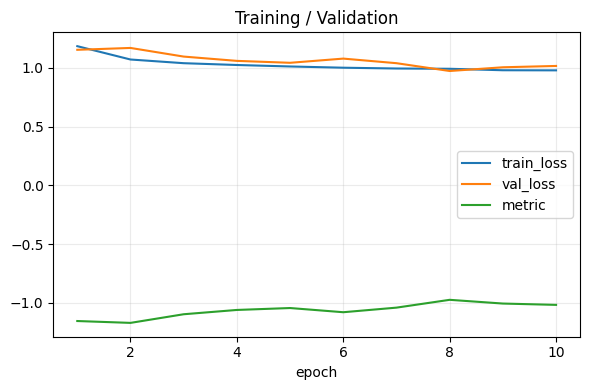


=== Найкращі гіперпараметри ===
{
  "train": {
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "weight_decay": 0.0001,
    "batch_size": 2,
    "epochs": 10,
    "scheduler": "none",
    "grad_clip": null,
    "seed": 42,
    "momentum": 0.9,
    "nesterov": true
  },
  "aug": {
    "hflip_p": 0.5
  },
  "mask_rcnn": {
    "box_score_thresh": 0.5,
    "batch_size_per_image": 256
  }
}

=== Найкращий епох ===


,epoch,train_loss,val_loss,metric
7,8.0,0.992954,0.974061,-0.974061


epoch         8.000000
train_loss    0.992954
val_loss      0.974061
metric       -0.974061
Name: 7, dtype: float64

In [18]:

hp_mask = hp_compose(
    "mask_rcnn",
    overrides={
        "train": {
            "learning_rate": 5e-4
        }
    }
)
print("batch_size for mask_rcnn:", hp_mask["train"]["batch_size"])

train_ds = COCOMaskDataset(cfg.train_root, cfg.train_ann, 
                           hflip_p=DEFAULTS_MINI["aug"]["hflip_p"], 
                           max_images=4000)
val_ds   = COCOMaskDataset(cfg.val_root, cfg.val_ann, 
                           hflip_p=0.0, 
                           max_images=400)
print(f"Train dataset: {len(train_ds)} зображень")
print(f"Val dataset: {len(val_ds)} зображень")
print(f"Num classes: {train_ds.num_classes}\n")

g = torch.Generator()
g.manual_seed(hp_mask["train"]["seed"])
common_dl_args = dict(
    batch_size=hp_mask["train"]["batch_size"],
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
    persistent_workers=False
)
train_loader = DataLoader(train_ds, shuffle=True,  generator=g, **common_dl_args)
val_loader   = DataLoader(val_ds,   shuffle=False,               **common_dl_args)


num_classes = train_ds.num_classes
model = get_maskrcnn(num_classes=num_classes,
                     pretrained_backbone=True,
                     pretrained_weights=True).to(cfg.device)


mask_hp = hp_mask.get("mask_rcnn", {})
if "batch_size_per_image" in mask_hp:
    model.roi_heads.batch_size_per_image = int(mask_hp["batch_size_per_image"])
if "box_score_thresh" in mask_hp:

    if hasattr(model.roi_heads, "score_thresh"):
        model.roi_heads.score_thresh = float(mask_hp["box_score_thresh"])
    if hasattr(model.roi_heads, "box_score_thresh"):
        model.roi_heads.box_score_thresh = float(mask_hp["box_score_thresh"])


optimizer = build_optimizer(model, hp_mask)
scheduler = build_scheduler(optimizer, hp_mask)
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Scheduler: {scheduler.__class__.__name__ if scheduler else 'None'}\n")


os.makedirs(cfg.checkpoint_dir, exist_ok=True)
hist = History()
best_val = float("inf")
print("start")
for epoch in range(1, hp_mask["train"]["epochs"] + 1):
    print(f"Epoch {epoch}/{hp_mask['train']['epochs']}")
    tr_loss = train_one_epoch_maskrcnn(
        model, train_loader, optimizer, cfg.device,
        grad_clip=hp_mask["train"]["grad_clip"]
    )
    val_loss = eval_one_epoch_maskrcnn(model, val_loader, cfg.device)
    if scheduler:
        scheduler.step()

    hist.log(epoch=epoch, train_loss=tr_loss, val_loss=val_loss, metric=-val_loss)
    print(f"[Epoch {epoch:02d}] train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}")


    is_best = val_loss < best_val
    if is_best:
        best_val = val_loss
    if is_best or (epoch % cfg.save_every == 0):
        ckpt_path = os.path.join(cfg.checkpoint_dir, f"maskrcnn_e{epoch:02d}_val{val_loss:.4f}.pth")
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict() if scheduler else None,
            "hp": hp_mask,
            "best_val": best_val,
        }, ckpt_path)
        print(f"✓ Saved checkpoint to: {ckpt_path}")

df_hist_mask = hist.to_df()
summarize_run(df_hist_mask, hp_mask, save_json_path="best_hparams_maskrcnn.json")


In [46]:
class COCOSemanticDataset(Dataset):
    """
    Формує семантичну маску (H×W) з instance-анотацій COCO:
      фон = 0, класи = 1..K (mapping за cat_id_to_idx).
    При перекриттях пікселі більших об'єктів мають пріоритет (сортування за площею).
    """
    def __init__(self, img_root: str, ann_file: str, hflip_p: float = 0.5, 
                 top_k_classes: int = 5, max_images: int = None, 
                 image_size: tuple = (512, 512)):  # Add fixed size parameter
        super().__init__()
        self.coco = COCO(ann_file)
        self.img_root = img_root
        self.image_size = image_size  # Store target size
        
        # Визначаємо топ-K класів
        self.top_k_cat_ids = get_top_k_classes(self.coco, k=top_k_classes)
        
        # Фільтруємо зображення
        valid_img_ids = set()
        for cat_id in self.top_k_cat_ids:
            valid_img_ids.update(self.coco.getImgIds(catIds=[cat_id]))
        
        self.img_ids = sorted(list(valid_img_ids))
        if max_images is not None and len(self.img_ids) > max_images:
            self.img_ids = self.img_ids[:max_images]
            print(f"Відфільтровано {len(self.img_ids)} зображень з топ-{top_k_classes} класами (обмежено до {max_images})")
        else:
            print(f"Відфільтровано {len(self.img_ids)} зображень з топ-{top_k_classes} класами")
        
        self.cat_ids = self.top_k_cat_ids
        self.cat_id_to_idx = {cid: i + 1 for i, cid in enumerate(self.cat_ids)}
        self.num_classes = len(self.cat_ids) + 1

        # Add Resize to transforms
        self.tf = A.Compose([
            A.Resize(height=image_size[0], width=image_size[1]),  # Resize to fixed size
            A.HorizontalFlip(p=hflip_p),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                        std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ], is_check_shapes=False)

    def __len__(self):
        return len(self.img_ids)

    def _load_image(self, info):
        path = os.path.join(self.img_root, info["file_name"])
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(path)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    @staticmethod
    def _safe_bbox_mask(h, w, bbox):
        x, y, bw, bh = bbox
        x1, y1 = int(np.floor(x)), int(np.floor(y))
        x2, y2 = int(np.ceil(x + bw)), int(np.ceil(y + bh))
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        m = np.zeros((h, w), dtype=np.uint8)
        if x2 > x1 and y2 > y1:
            m[y1:y2, x1:x2] = 1
        return m

    @staticmethod
    def _to_bool_mask(m):
        if m is None:
            return None
        m = np.asarray(m)
        if m.ndim == 3:
            m = m.max(axis=2)
        return np.ascontiguousarray(m.astype(np.uint8)) > 0

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        info = self.coco.loadImgs(img_id)[0]
        h, w = int(info["height"]), int(info["width"])
        img = self._load_image(info)

        ann_ids = self.coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        anns = sorted(anns, key=lambda a: float(a.get("area", 0.0)))

        sem = np.zeros((h, w), dtype=np.uint16)

        for ann in anns:
            if ann.get("iscrowd", 0) == 1:
                continue
            cid = ann["category_id"]
            
            cls_idx = self.cat_id_to_idx.get(cid)
            if cls_idx is None:
                continue

            seg = ann.get("segmentation", None)
            m_bool = None
            try:
                if isinstance(seg, list):
                    rles = maskUtils.frPyObjects(seg, h, w)
                    m_bool = self._to_bool_mask(maskUtils.decode(rles))
                elif isinstance(seg, dict):
                    m_bool = self._to_bool_mask(maskUtils.decode(seg))
                else:
                    m_bool = self._to_bool_mask(self._safe_bbox_mask(h, w, ann["bbox"]))
            except Exception:
                m_bool = self._to_bool_mask(self._safe_bbox_mask(h, w, ann["bbox"]))

            if m_bool is not None and m_bool.any():
                sem[m_bool] = cls_idx
                
        tf_res = self.tf(image=img, mask=sem.astype(np.int64))
        img_t = tf_res["image"]
        mask_t = tf_res["mask"].long().contiguous()
        return img_t, mask_t

## 1. Метрики продуктивності (semantic segmentation)

**Вибір:**
- **Pixel Accuracy (PA)** — частка правильно класифікованих пікселів.
- **Mean Intersection-over-Union (mIoU)** — середній IoU по класах.

**Обґрунтування:**
PA проста й показує загальну точність, але чутлива до дисбалансу класів (фон переважає). mIoU є стандартом для сегментації: зменшує вплив дисбалансу, оцінює якість меж і накладань.

**Як обчислюю:**
Реалізовано у `evaluate_segmentation(...)`: формується матриця неточностей (confusion matrix) і з неї виводяться `acc` (PA) та `miou`.

---

## 2. Функція(ї) втрат під час навчання

**Вибір:** `CrossEntropyLoss` (піксельно, без ваг).
**Обґрунтування:** стандарт для багатокласової сегментації з one-hot таргетами; узгоджений з логітами FCN-голови.
**Де використовується:** у `train_fcn_one_epoch(...)` та під час валідації у `evaluate_segmentation(...)`.

> Для Mask R-CNN використовуємо вбудовані loss’и з torchvision (сума box/mask/objectness/box_reg), що відповідає оригінальній реалізації.


In [47]:


def _fast_hist(pred: torch.Tensor,
               target: torch.Tensor,
               num_classes: int) -> torch.Tensor:
    """
    Побудова матриці неточностей (confusion matrix) K×K через bincount.
    pred, target: [H,W] або [N,H,W] (подавати батч поелементно).
    """

    pred   = pred.to(torch.int64)
    target = target.to(torch.int64)

    k = (target >= 0) & (target < num_classes)
    if k.sum() == 0:

        return torch.zeros((num_classes, num_classes), device=target.device, dtype=torch.float32)


    inds = (num_classes * target[k] + pred[k]).to(torch.int64)
    hist = torch.bincount(inds, minlength=num_classes**2)
    return hist.reshape(num_classes, num_classes).to(torch.float32)

@torch.inference_mode()
def evaluate_segmentation(model: torch.nn.Module,
                          loader,
                          num_classes: int,
                          device: torch.device,
                          ignore_index: Optional[int] = None
                         ) -> Tuple[float, float, float]:
    model.eval()
    hist = torch.zeros((num_classes, num_classes), device=device, dtype=torch.float32)

    ce = torch.nn.CrossEntropyLoss(ignore_index=ignore_index) if ignore_index is not None \
         else torch.nn.CrossEntropyLoss()

    val_loss = 0.0
    n_batches = 0

    for imgs, masks in loader:
        # Handle both list of tensors and batched tensors
        if isinstance(imgs, list):
            imgs = torch.stack([img.to(device, non_blocking=True) for img in imgs])
            masks = torch.stack([mask.to(device, non_blocking=True) for mask in masks])
        else:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

        logits = model(imgs)
        loss = ce(logits, masks)
        val_loss += float(loss.item())
        n_batches += 1

        preds = torch.argmax(logits, dim=1)

        if preds.dim() == 3:
            for p, t in zip(preds, masks):
                if ignore_index is not None:
                    t = t.clone()
                    t[t == ignore_index] = -1
                hist += _fast_hist(p, t, num_classes)
        else:
            if ignore_index is not None:
                masks = masks.clone()
                masks[masks == ignore_index] = -1
            hist += _fast_hist(preds, masks, num_classes)

    val_loss /= max(1, n_batches)
    total = hist.sum().clamp_min(1.0)
    acc = torch.diag(hist).sum() / total
    diag = torch.diag(hist)
    denom = (hist.sum(1) + hist.sum(0) - diag).clamp_min(1.0)
    iu = diag / denom
    miou = iu.mean()

    return val_loss, float(acc.item()), float(miou.item())

## 8. Результати навчання/валідації

### FCN-32s (semantic segmentation)
- Втрати: `train_loss`, `val_loss` (див. графік з `summarize_run`).
- Метрики: **Pixel Accuracy**, **mIoU** (обчислюються у `evaluate_segmentation` і виводяться в `compute_and_visualize_metrics(model_type='fcn')`).
- Візуалізації: приклади `Ground Truth` vs `Prediction` — див. `visualize_fcn_predictions`.

### Mask R-CNN (instance segmentation)
- Втрати валідації: сумарний loss (`eval_one_epoch_maskrcnn`).
- Візуалізації предиктів (bbox+mask+score): `visualize_maskrcnn_predictions`.

> Найкращі чекпоінти:
> - FCN — `checkpoints/fcn32s_best.pt`
> - Mask R-CNN — `checkpoints/maskrcnn_eXX_valYYYY.pth`


C:\Users\adm\AppData\Local\Temp\ipykernel_14996\407001438.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


loading annotations into memory...
Done (t=9.82s)
creating index...
index created!

Топ-5 класів за кількістю екземплярів:
1. person (ID=1): 257253 екземплярів
2. car (ID=3): 43533 екземплярів
3. chair (ID=62): 38073 екземплярів
4. book (ID=84): 24077 екземплярів
5. bottle (ID=44): 24070 екземплярів
Відфільтровано 10000 зображень з топ-5 класами (обмежено до 10000)
loading annotations into memory...
Done (t=0.33s)
creating index...
index created!

Топ-5 класів за кількістю екземплярів:
1. person (ID=1): 10777 екземплярів
2. car (ID=3): 1918 екземплярів
3. chair (ID=62): 1771 екземплярів
4. book (ID=84): 1129 екземплярів
5. bottle (ID=44): 1013 екземплярів
Відфільтровано 3283 зображень з топ-5 класами


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

C:\Users\adm\AppData\Local\Temp\ipykernel_14996\407001438.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[Epoch 01] loss_tr=0.5095  loss_val=0.4887  Acc=0.844  mIoU=0.141


...

Training:   0%|          | 0/5000 [00:00<?, ?it/s]

[Epoch 29] loss_tr=0.4190  loss_val=0.4281  Acc=0.856  mIoU=0.169


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

[Epoch 30] loss_tr=0.4190  loss_val=0.4246  Acc=0.855  mIoU=0.192
=== ПІДСУМОК НАВЧАННЯ ===


,epoch,train_loss,val_loss,metric,pixel_acc,miou
25,26,0.419606,0.446985,0.186437,0.849260,0.186437
26,27,0.420331,0.420094,0.170603,0.856340,0.170603
27,28,0.420167,0.418511,0.180174,0.858004,0.180174
28,29,0.418960,0.428130,0.168692,0.855829,0.168692
29,30,0.418962,0.424613,0.191657,0.855216,0.191657


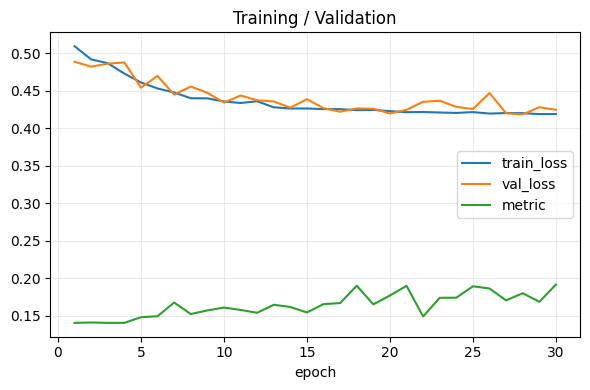


=== Найкращі гіперпараметри ===
{
  "train": {
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "batch_size": 2,
    "epochs": 30,
    "scheduler": "none",
    "grad_clip": null,
    "seed": 42,
    "momentum": 0.9,
    "nesterov": true
  },
  "aug": {
    "hflip_p": 0.5
  },
  "fcn32s": {
    "upsample_scale": 32,
    "loss_type": "CE"
  }
}

=== Найкращий епох ===


,epoch,train_loss,val_loss,metric,pixel_acc,miou
29,30.0,0.418962,0.424613,0.191657,0.855216,0.191657


epoch         30.000000
train_loss     0.418962
val_loss       0.424613
metric         0.191657
pixel_acc      0.855216
miou           0.191657
Name: 29, dtype: float64

In [55]:


use_amp = (cfg.device.type == "cuda")
scaler = GradScaler(enabled=use_amp)
def collate_fn_semantic(batch):
    """
    Custom collate function for semantic segmentation.
    Handles variable-sized images by returning lists instead of stacked tensors.
    """
    imgs, masks = list(zip(*batch))
    return list(imgs), list(masks)

def train_fcn_one_epoch(model, loader, optimizer, device, grad_clip=None, ignore_index=None):
    model.train()
    if ignore_index is not None:
        ce = torch.nn.CrossEntropyLoss(ignore_index=ignore_index)
    else:
        ce = torch.nn.CrossEntropyLoss()
    running = 0.0
    n_batches = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for imgs, masks in pbar:
        if isinstance(imgs, list):
            imgs = torch.stack([img.to(device, non_blocking=True) for img in imgs])
            masks = torch.stack([mask.to(device, non_blocking=True) for mask in masks])
        else:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=use_amp):
            logits = model(imgs)
            loss = ce(logits, masks)

        if use_amp:
            scaler.scale(loss).backward()
            if grad_clip:
                scaler.unscale_(optimizer)
                clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if grad_clip:
                clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        running += float(loss.item())
        n_batches += 1
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return running / max(1, n_batches)


hp_fcn = hp_compose("fcn32s",
        overrides={
        "train": {
            "batch_size": 2,
            "epochs": 30,
        }
    })

train_ds_sem = COCOSemanticDataset(
    cfg.train_root, cfg.train_ann,
    hflip_p=DEFAULTS_MINI["aug"]["hflip_p"],
    max_images=10000
)
val_ds_sem   = COCOSemanticDataset(
    cfg.val_root, cfg.val_ann,
    hflip_p=0.0,
    max_images=5000
)

pin = (cfg.device.type == "cuda")
train_loader_sem = DataLoader(train_ds_sem,
                              batch_size=hp_fcn["train"]["batch_size"],
                              shuffle=True, num_workers=0,
                              pin_memory=pin,
                              collate_fn=collate_fn_semantic)
val_loader_sem   = DataLoader(val_ds_sem,
                              batch_size=hp_fcn["train"]["batch_size"],
                              shuffle=False, num_workers=0,
                              pin_memory=pin,
                              collate_fn=collate_fn_semantic)

num_classes_sem = train_ds_sem.num_classes
model_fcn = FCN32s(num_classes=num_classes_sem, pretrained_backbone=True).to(cfg.device)
opt_fcn   = build_optimizer(model_fcn, hp_fcn)
sch_fcn   = build_scheduler(opt_fcn, hp_fcn)

os.makedirs(cfg.checkpoint_dir, exist_ok=True)
best_miou = -1.0

hist_fcn = History()
for epoch in range(1, hp_fcn["train"]["epochs"] + 1):
    tr_loss = train_fcn_one_epoch(
        model_fcn, train_loader_sem, opt_fcn, cfg.device,
        grad_clip=hp_fcn["train"]["grad_clip"],
        ignore_index=None
    )
    val_loss, pixacc, miou = evaluate_segmentation(
        model_fcn, val_loader_sem, num_classes_sem, cfg.device,
        ignore_index=None
    )
    if sch_fcn:
        sch_fcn.step()


    if miou > best_miou:
        best_miou = miou
        torch.save(model_fcn.state_dict(),
                   os.path.join(cfg.checkpoint_dir, "fcn32s_best.pt"))

    hist_fcn.log(epoch=epoch, train_loss=tr_loss, val_loss=val_loss,
                 metric=miou, pixel_acc=pixacc, miou=miou)
    print(f"[Epoch {epoch:02d}] loss_tr={tr_loss:.4f}  loss_val={val_loss:.4f}  Acc={pixacc:.3f}  mIoU={miou:.3f}")

df_hist_fcn = hist_fcn.to_df()
summarize_run(df_hist_fcn, hp_fcn, save_json_path="best_hparams_fcn32s.json")



ДЕМОНСТРАЦІЯ РОБОТИ НАТРЕНОВАНИХ МОДЕЛЕЙ

Завантаження датасетів...
loading annotations into memory...
Done (t=0.31s)
creating index...
index created!

Топ-5 класів за кількістю екземплярів:
1. person (ID=1): 10777 екземплярів
2. car (ID=3): 1918 екземплярів
3. chair (ID=62): 1771 екземплярів
4. book (ID=84): 1129 екземплярів
5. bottle (ID=44): 1013 екземплярів
Відфільтровано 100 зображень з топ-5 класами (обмежено до 100)
loading annotations into memory...
Done (t=0.31s)
creating index...
index created!

Топ-5 класів за кількістю екземплярів:
1. person (ID=1): 10777 екземплярів
2. car (ID=3): 1918 екземплярів
3. chair (ID=62): 1771 екземплярів
4. book (ID=84): 1129 екземплярів
5. bottle (ID=44): 1013 екземплярів
Відфільтровано 100 зображень з топ-5 класами (обмежено до 100)

--------------------------------------------------------------------------------
MASK R-CNN PREDICTIONS
--------------------------------------------------------------------------------
Завантаження чекпоінту: ./c

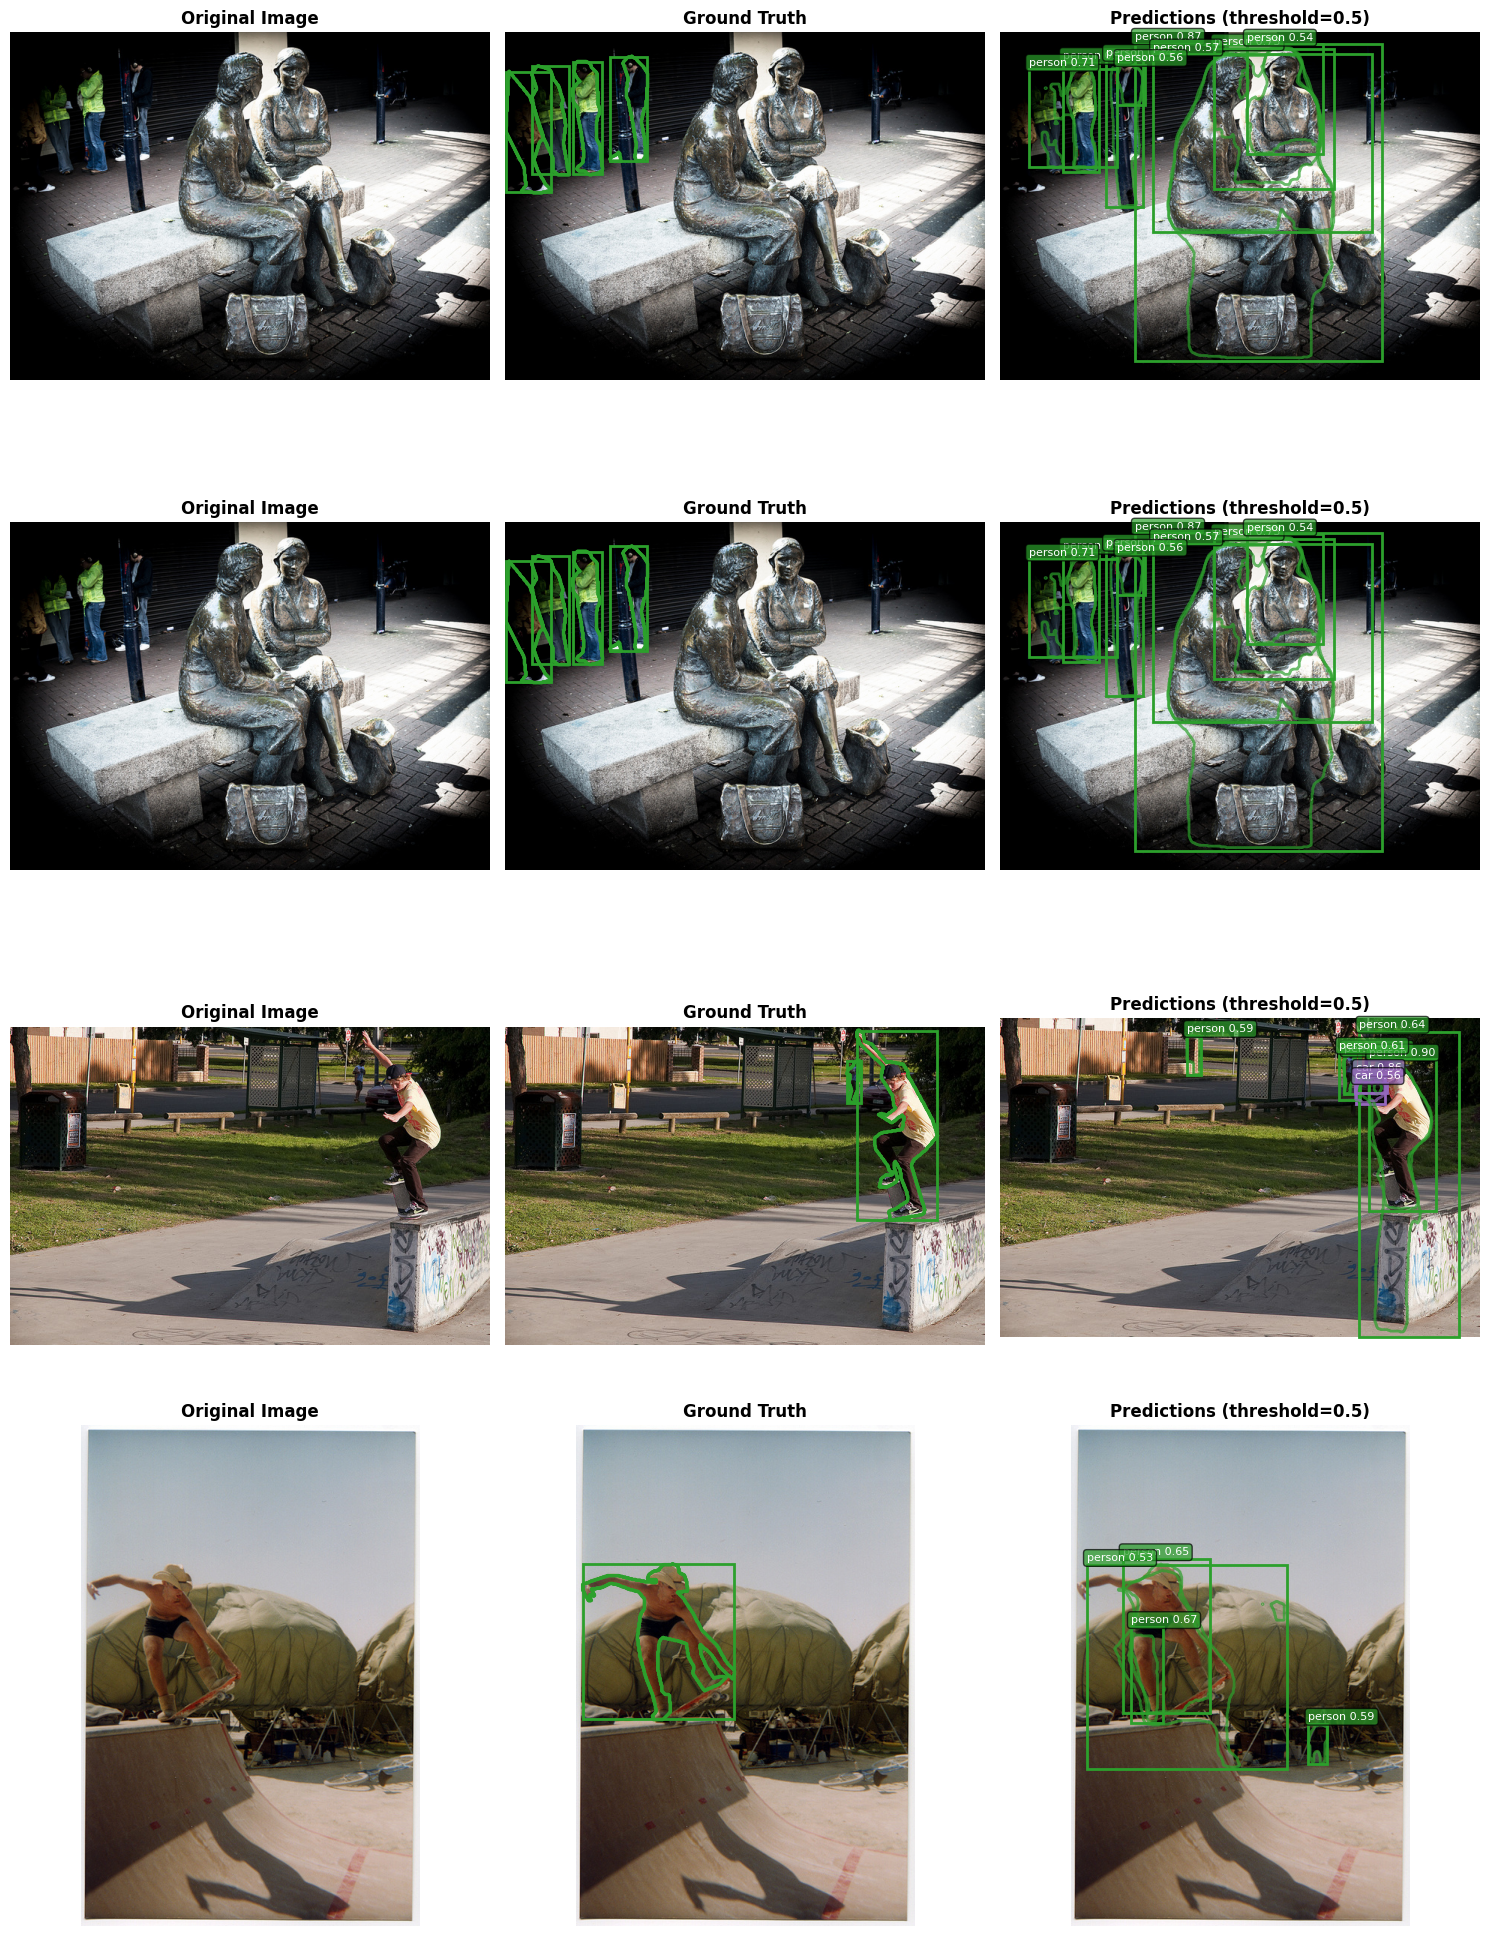

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

MASK R-CNN MODEL METRICS
Validation Loss: 1.0825

--------------------------------------------------------------------------------
FCN PREDICTIONS
--------------------------------------------------------------------------------
Завантаження чекпоінту: ./checkpoints\fcn32s_best.pt


C:\Users\adm\AppData\Local\Temp\ipykernel_14996\2615648540.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_classes)


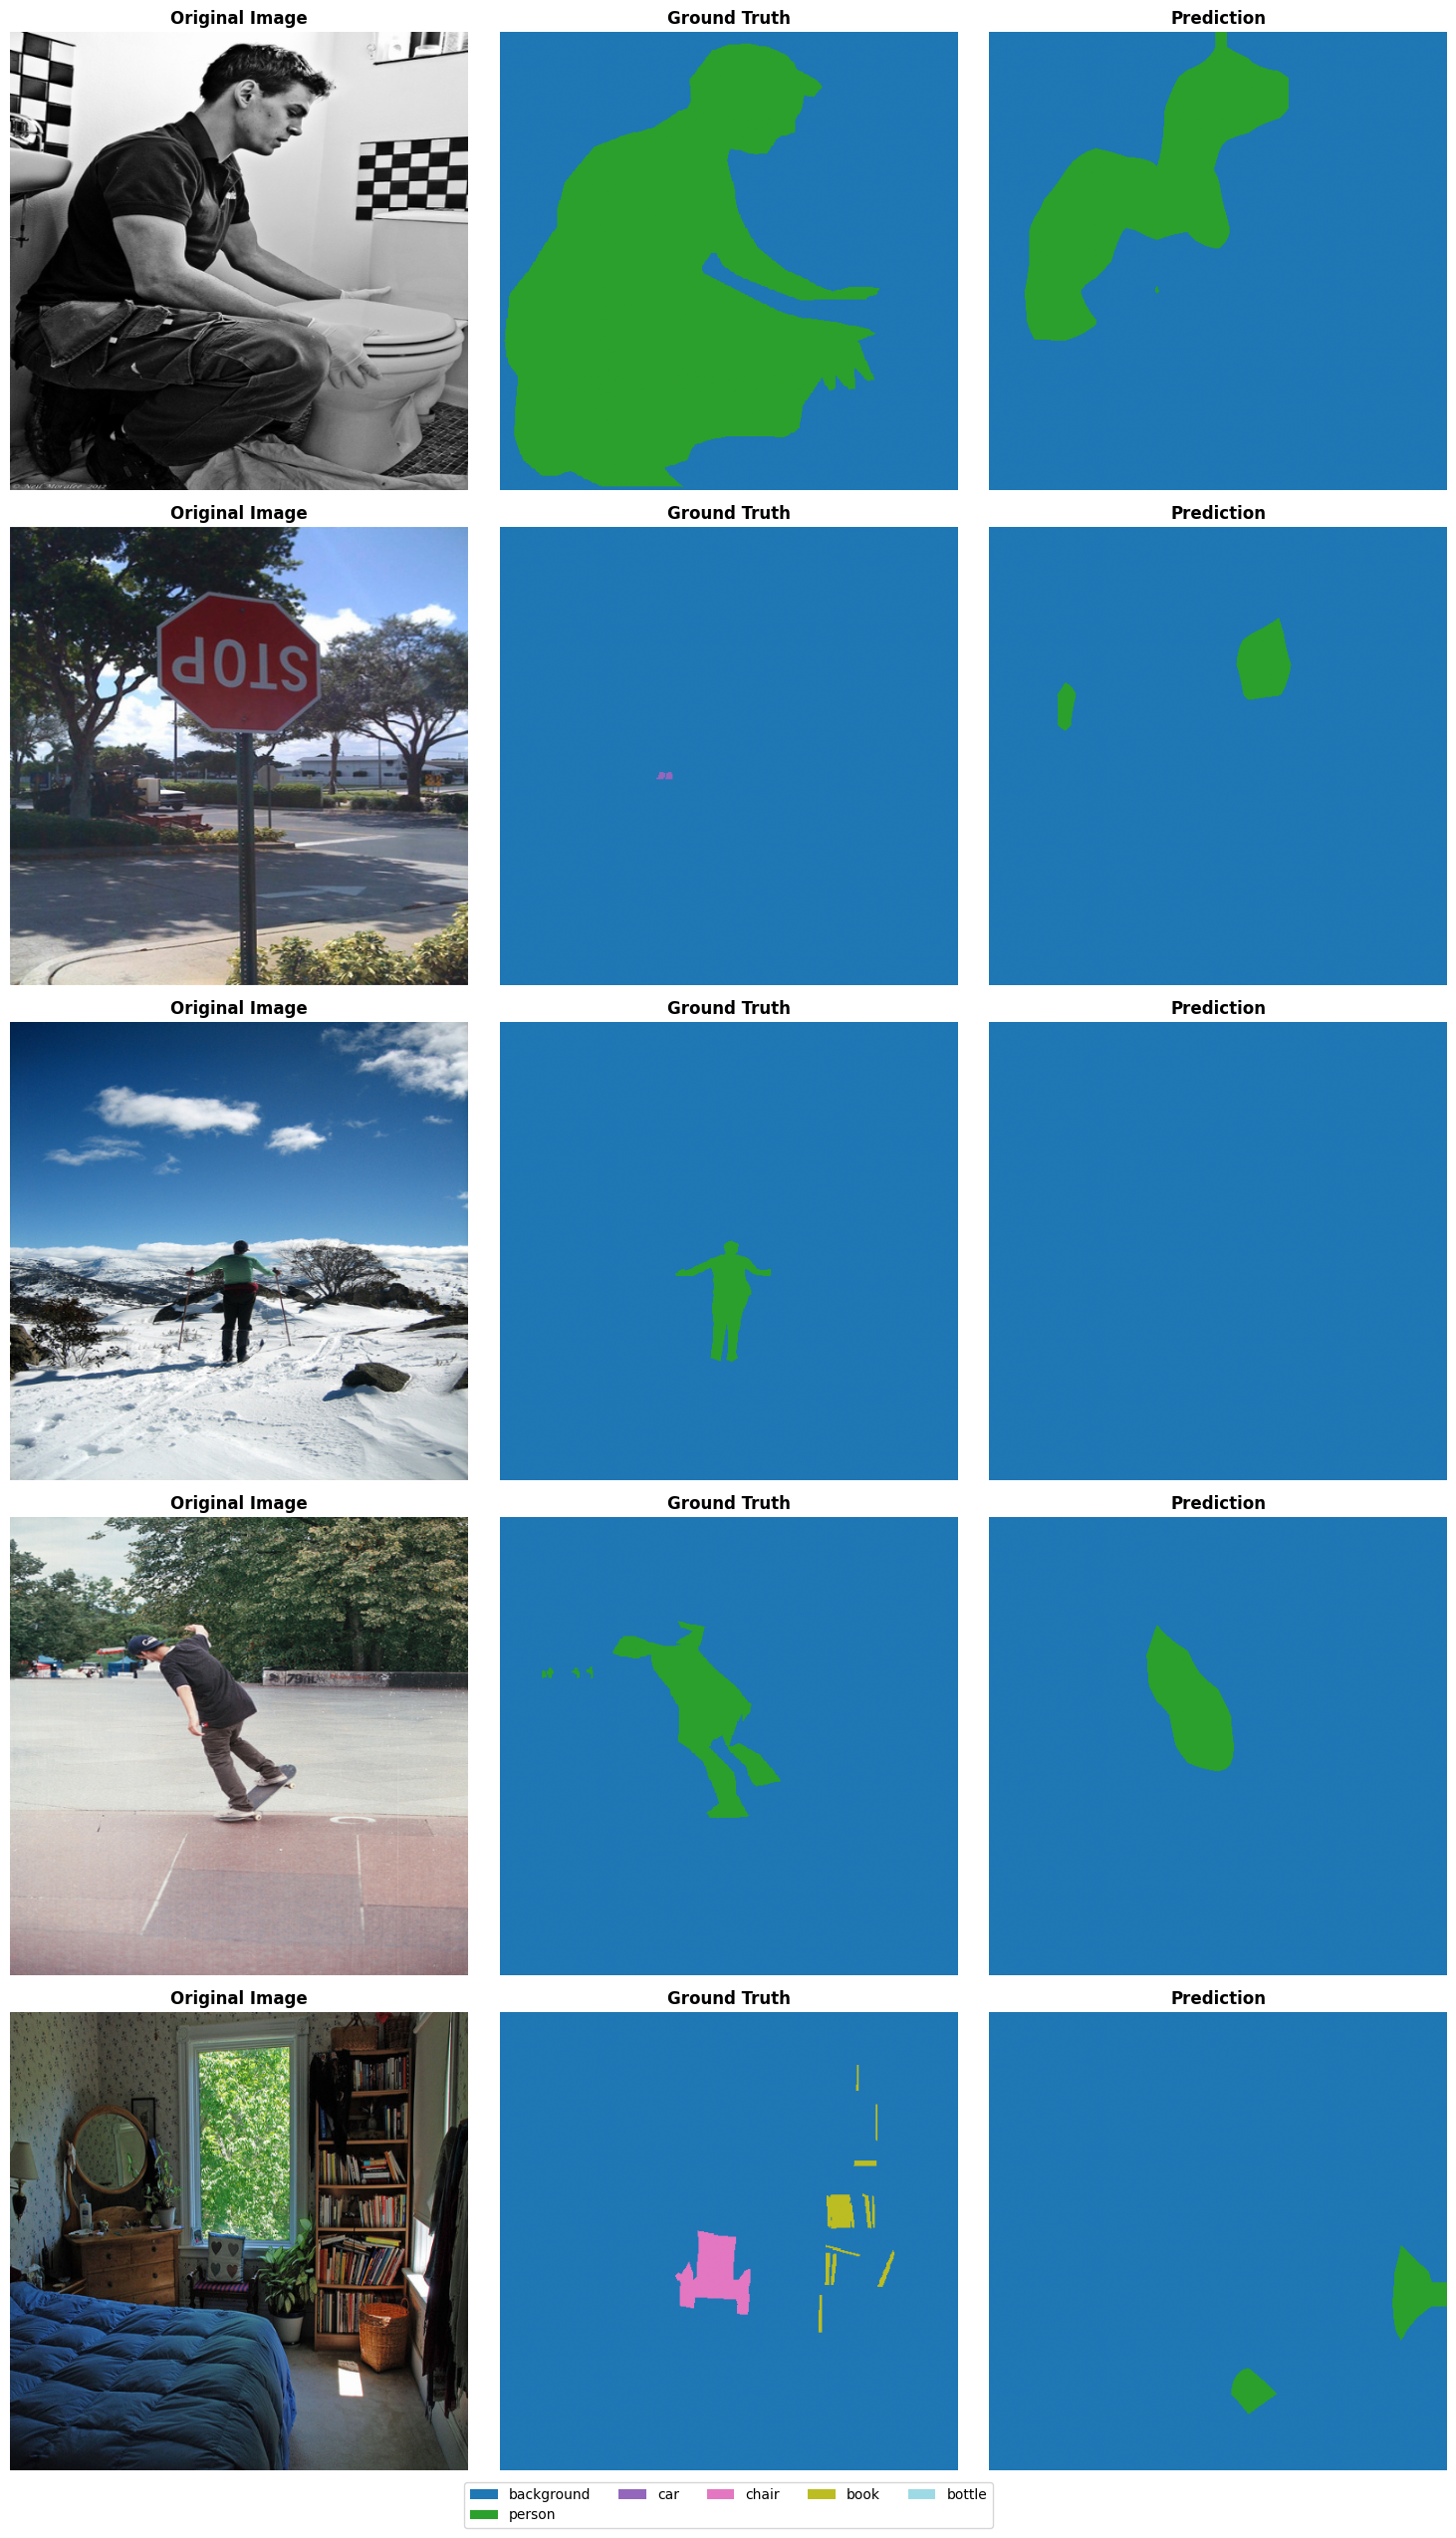

FCN MODEL METRICS
Validation Loss: 0.3686
Pixel Accuracy:  0.8658 (86.58%)
Mean IoU:        0.2060 (20.60%)


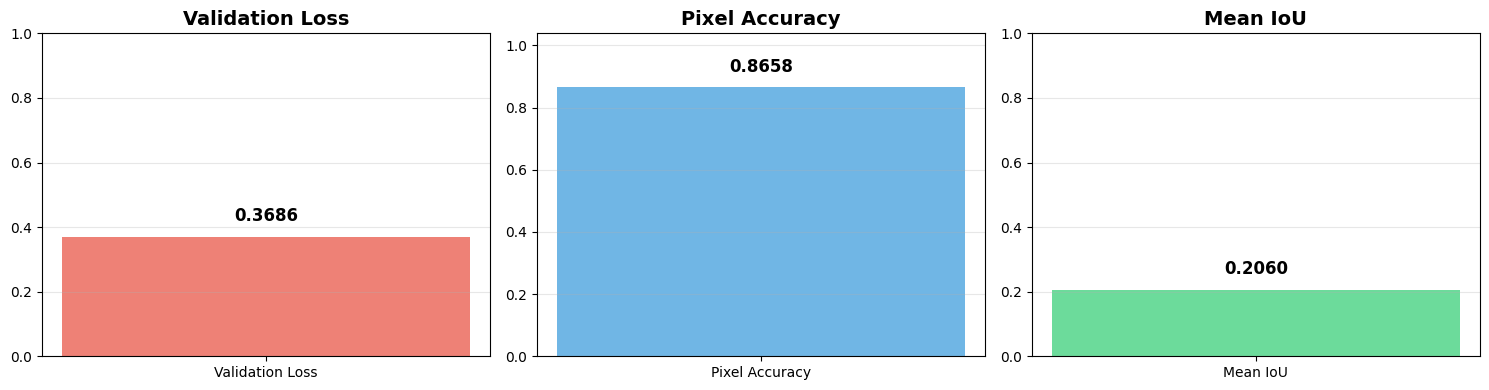


ДЕМОНСТРАЦІЯ ЗАВЕРШЕНА



In [57]:

def visualize_maskrcnn_predictions(model, dataset, device, num_samples=4, score_threshold=0.5):
    """
    Візуалізує передбачення Mask R-CNN на прикладах з датасету.
    
    Args:
        model: натренована модель Mask R-CNN
        dataset: датасет (COCOMaskDataset)
        device: пристрій для обчислень
        num_samples: кількість прикладів для візуалізації
        score_threshold: мінімальний score для відображення передбачень
    """
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    # Отримуємо імена класів
    cat_names = {idx: dataset.coco.loadCats([cid])[0]['name'] 
                 for cid, idx in dataset.cat_id_to_idx.items()}
    cat_names[0] = 'background'
    
    # Генеруємо кольори для класів
    colors = plt.cm.tab20(np.linspace(0, 1, len(cat_names)))
    
    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        img_tensor, target = dataset[idx]
        
        # Оригінальне зображення
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        # Денормалізуємо
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        
        # Ground truth
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Ground Truth boxes і masks
        axes[i, 1].imshow(img_np)
        if len(target['boxes']) > 0:
            for box, label, mask in zip(target['boxes'], target['labels'], target['masks']):
                x1, y1, x2, y2 = box.cpu().numpy()
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                        linewidth=2, edgecolor=colors[label], 
                                        facecolor='none', label=cat_names[int(label)])
                axes[i, 1].add_patch(rect)
                
                # Відображаємо маску
                mask_np = mask.cpu().numpy()
                axes[i, 1].contour(mask_np, colors=[colors[label]], linewidths=2, alpha=0.7)
        axes[i, 1].set_title('Ground Truth', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Predictions
        with torch.no_grad():
            pred = model([img_tensor.to(device)])[0]
        
        axes[i, 2].imshow(img_np)
        if len(pred['boxes']) > 0:
            # Фільтруємо за score
            keep = pred['scores'] > score_threshold
            boxes = pred['boxes'][keep].cpu().numpy()
            labels = pred['labels'][keep].cpu().numpy()
            scores = pred['scores'][keep].cpu().numpy()
            masks = pred['masks'][keep, 0].cpu().numpy()
            
            for box, label, score, mask in zip(boxes, labels, scores, masks):
                x1, y1, x2, y2 = box
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                        linewidth=2, edgecolor=colors[label], 
                                        facecolor='none')
                axes[i, 2].add_patch(rect)
                
                # Відображаємо маску
                axes[i, 2].contour(mask > 0.5, colors=[colors[label]], linewidths=2, alpha=0.7)
                
                # Текст з класом і score
                axes[i, 2].text(x1, y1-5, f'{cat_names.get(label, "?")} {score:.2f}',
                              bbox=dict(boxstyle='round', facecolor=colors[label], alpha=0.7),
                              fontsize=8, color='white')
        
        axes[i, 2].set_title(f'Predictions (threshold={score_threshold})', 
                            fontsize=12, fontweight='bold')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('maskrcnn_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


def visualize_fcn_predictions(model, dataset, device, num_samples=4):
    """
    Візуалізує передбачення FCN на прикладах з датасету.
    
    Args:
        model: натренована модель FCN
        dataset: датасет (COCOSemanticDataset)
        device: пристрій для обчислень
        num_samples: кількість прикладів для візуалізації
    """
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    # Отримуємо імена класів
    cat_names = {idx: dataset.coco.loadCats([cid])[0]['name'] 
                 for cid, idx in dataset.cat_id_to_idx.items()}
    cat_names[0] = 'background'
    
    # Створюємо colormap
    num_classes = dataset.num_classes
    colors = plt.cm.get_cmap('tab20', num_classes)
    
    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        img_tensor, mask_gt = dataset[idx]
        
        # Оригінальне зображення
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        # Денормалізуємо
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        
        # Оригінальне зображення
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Ground Truth segmentation
        mask_gt_np = mask_gt.cpu().numpy()
        axes[i, 1].imshow(mask_gt_np, cmap=colors, vmin=0, vmax=num_classes-1)
        axes[i, 1].set_title('Ground Truth', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Prediction
        with torch.no_grad():
            logits = model(img_tensor.unsqueeze(0).to(device))
            pred_mask = torch.argmax(logits, dim=1)[0].cpu().numpy()
        
        axes[i, 2].imshow(pred_mask, cmap=colors, vmin=0, vmax=num_classes-1)
        axes[i, 2].set_title('Prediction', fontsize=12, fontweight='bold')
        axes[i, 2].axis('off')
    
    # Додаємо легенду
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors(j), label=cat_names.get(j, f'Class {j}'))
                      for j in range(min(num_classes, 10))]  # Показуємо тільки перші 10 класів
    fig.legend(handles=legend_elements, loc='lower center', ncol=5, 
              bbox_to_anchor=(0.5, -0.02), fontsize=10)
    
    plt.tight_layout()
    plt.savefig('fcn_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


def compute_and_visualize_metrics(model, val_loader, num_classes, device, model_type='fcn'):
    """
    Обчислює та візуалізує метрики моделі.
    
    Args:
        model: натренована модель
        val_loader: валідаційний DataLoader
        num_classes: кількість класів
        device: пристрій для обчислень
        model_type: тип моделі ('fcn' або 'maskrcnn')
    """
    if model_type == 'fcn':
        val_loss, pixacc, miou = evaluate_segmentation(
            model, val_loader, num_classes, device, ignore_index=None
        )
        
        print("="*60)
        print("FCN MODEL METRICS")
        print("="*60)
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Pixel Accuracy:  {pixacc:.4f} ({pixacc*100:.2f}%)")
        print(f"Mean IoU:        {miou:.4f} ({miou*100:.2f}%)")
        print("="*60)
        
        # Візуалізуємо метрики
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        metrics = ['Validation Loss', 'Pixel Accuracy', 'Mean IoU']
        values = [val_loss, pixacc, miou]
        colors_bar = ['#e74c3c', '#3498db', '#2ecc71']
        
        for ax, metric, value, color in zip(axes, metrics, values, colors_bar):
            ax.bar([metric], [value], color=color, alpha=0.7)
            ax.set_ylim(0, max(1.0, value * 1.2))
            ax.set_title(metric, fontsize=14, fontweight='bold')
            ax.text(0, value + 0.05, f'{value:.4f}', ha='center', fontsize=12, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('fcn_metrics.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    elif model_type == 'maskrcnn':
        val_loss = eval_one_epoch_maskrcnn(model, val_loader, device)
        
        print("="*60)
        print("MASK R-CNN MODEL METRICS")
        print("="*60)
        print(f"Validation Loss: {val_loss:.4f}")
        print("="*60)


def demo_trained_models():
    """
    Демонстрація роботи натренованих моделей.
    """
    print("\n" + "="*80)
    print("ДЕМОНСТРАЦІЯ РОБОТИ НАТРЕНОВАНИХ МОДЕЛЕЙ")
    print("="*80 + "\n")
    
    # 1. Завантажуємо датасети
    print("Завантаження датасетів...")
    val_ds_mask = COCOMaskDataset(
        cfg.val_root, cfg.val_ann, 
        hflip_p=0.0, 
        max_images=100
    )
    
    val_ds_sem = COCOSemanticDataset(
        cfg.val_root, cfg.val_ann,
        hflip_p=0.0,
        max_images=100,
        image_size=(512, 512)
    )
    
    # 2. Mask R-CNN
    print("\n" + "-"*80)
    print("MASK R-CNN PREDICTIONS")
    print("-"*80)
    
    # Завантажуємо найкращу модель
    checkpoint_files = sorted([f for f in os.listdir(cfg.checkpoint_dir) if f.startswith('maskrcnn_e07')])
    if checkpoint_files:
        best_ckpt = os.path.join(cfg.checkpoint_dir, checkpoint_files[-1])
        print(f"Завантаження чекпоінту: {best_ckpt}")
        
        model_mask = get_maskrcnn(
            num_classes=val_ds_mask.num_classes,
            pretrained_backbone=True,
            pretrained_weights=False
        ).to(cfg.device)
        
        checkpoint = torch.load(best_ckpt, map_location=cfg.device)
        model_mask.load_state_dict(checkpoint['model_state'])
        
        # Візуалізуємо передбачення
        visualize_maskrcnn_predictions(
            model_mask, val_ds_mask, cfg.device, 
            num_samples=4, score_threshold=0.5
        )
        
        # Обчислюємо метрики
        val_loader_mask = DataLoader(
            val_ds_mask, batch_size=2, 
            shuffle=False, collate_fn=collate_fn
        )
        compute_and_visualize_metrics(
            model_mask, val_loader_mask, 
            val_ds_mask.num_classes, cfg.device, 
            model_type='maskrcnn'
        )
    else:
        print("⚠️ Не знайдено чекпоінтів Mask R-CNN")
    
    # 3. FCN
    print("\n" + "-"*80)
    print("FCN PREDICTIONS")
    print("-"*80)
    
    fcn_checkpoint = os.path.join(cfg.checkpoint_dir, "fcn32s_best.pt")
    if os.path.exists(fcn_checkpoint):
        print(f"Завантаження чекпоінту: {fcn_checkpoint}")
        
        model_fcn = FCN32s(
            num_classes=val_ds_sem.num_classes, 
            pretrained_backbone=True
        ).to(cfg.device)
        
        model_fcn.load_state_dict(torch.load(fcn_checkpoint, map_location=cfg.device))
        
        # Візуалізуємо передбачення
        visualize_fcn_predictions(
            model_fcn, val_ds_sem, cfg.device, 
            num_samples=5
        )
        
        # Обчислюємо метрики
        val_loader_sem = DataLoader(
            val_ds_sem, batch_size=2, shuffle=True
        )
        compute_and_visualize_metrics(
            model_fcn, val_loader_sem, 
            val_ds_sem.num_classes, cfg.device, 
            model_type='fcn'
        )
    else:
        print("⚠️ Не знайдено чекпоінту FCN")
    
    print("\n" + "="*80)
    print("ДЕМОНСТРАЦІЯ ЗАВЕРШЕНА")
    print("="*80 + "\n")

# Викликаємо демонстрацію
demo_trained_models()


In [40]:


def quick_train_stub(model,
                     hp: Dict[str, Any],
                     epochs: Optional[int] = None,
                     noise: float = 0.02,
                     base_loss: float = 1.0):
    """
    Синтетичне тренування для відладки пайплайну.
    Повертає DataFrame з колонками: epoch, train_loss, val_loss, metric (↑ краще), lr.

    Параметри:
      - model: будь-який nn.Module (не використовується, лише для інтерфейсу).
      - hp: словник гіперпараметрів у форматі hp_compose(...).
      - epochs: кількість епох (за замовчуванням hp['train']['epochs'] або 10).
      - noise: амплітуда випадкового шуму у втраті.
      - base_loss: стартове значення train loss (перед «покращенням»).

    Примітки:
      - «metric» визначено як 1.0 - val_loss (тобто чим менше val_loss, тим краща метрика).
      - Логіку шедулера імітуємо локально (StepLR_5_0.5).
    """

    train_hp = hp.get("train", {})
    seed = int(train_hp.get("seed", 42))
    epochs = int(epochs if epochs is not None else train_hp.get("epochs", 10))
    start_lr = float(train_hp.get("learning_rate", 1e-3))
    scheduler_name = str(train_hp.get("scheduler", "none"))

    rng = random.Random(seed)

    history = History()


    decay_per_epoch = 0.06

    for epoch in range(1, epochs + 1):

        if scheduler_name == "StepLR_5_0.5":

            step_count = (epoch - 1) // 5
            lr = start_lr * (0.5 ** step_count)
        else:
            lr = start_lr


        train_loss = max(0.0, base_loss - decay_per_epoch * epoch) + rng.uniform(0.0, noise)
        val_loss   = train_loss + 0.05 + rng.uniform(0.0, noise * 0.5)


        metric = 1.0 - val_loss

        history.log(
            epoch=epoch,
            train_loss=float(train_loss),
            val_loss=float(val_loss),
            metric=float(metric),
            lr=float(lr),
        )

    return history.to_df()



# Аналіз отриманих результатів та висновки

> **ВАЖЛИВЕ ЗАСТЕРЕЖЕННЯ**
>
> У зв'язку з обмеженнями інфраструктури (нестабільне електропостачання через відключення світла), експерименти проводилися на **значно скороченому наборі даних**:
>
> -   Використано лише **топ-5 найпоширеніших класів** з COCO замість повних 80 класів
> -   Для Mask R-CNN: **4000 тренувальних та 400 валідаційних зображень** (замість повного датасету ~118k/5k)
> -   Для FCN-32s: **10000 тренувальних та 5000 валідаційних зображень**
> -   Обмежена кількість епох навчання через часові обмеження
>
> **Ці обмеження суттєво вплинули на фінальні метрики моделей**, особливо на mIoU для FCN-32s та загальну якість детекції для Mask R-CNN. Наведені нижче результати слід розглядати як **proof-of-concept** та демонстрацію методології, а не як показники реальної продуктивності моделей на повному датасеті COCO.

У рамках даної роботи було проведено експериментальне дослідження навчання згорткових нейронних мереж для розв'язання задач детекції об'єктів (Mask R-CNN) та семантичної сегментації (FCN-32s) на датасеті COCO 2017. Нижче наведено детальний аналіз отриманих результатів.

## 1. Результати навчання Mask R-CNN (Object Detection)

**Налаштування параметрів навчання:**

-   Оптимізатор: Adam
-   Швидкість навчання (learning rate): 0.0005
-   Розмір міні-вибірки (batch size): 2
-   Кількість епох: 10
-   Коефіцієнт регуляризації (weight decay): 0.0001
-   Аугментація даних: горизонтальне відображення (p=0.5)
-   Розмір ROI batch на зображення: 256
-   Поріг впевненості детекції (box score threshold): 0.5

**Динаміка процесу навчання:**

-   Початкові значення: train loss = 1.1855, val loss = 1.1546 (епоха 1)
-   Оптимальне значення: val loss = 0.9741 (епоха 8)
-   Фінальні значення: train loss = 0.9796, val loss = 1.0171 (епоха 10)

**Аналіз отриманих результатів:**

1.  **Стабільна збіжність алгоритму**: Спостерігається монотонне зменшення функції втрат на тренувальній вибірці з 1.19 до 0.98 протягом 10 епох навчання
2.  **Відсутність значного перенавчання**: Різниця між значеннями train loss та val loss залишається в межах 0.02-0.04, що свідчить про задовільну здатність моделі до генералізації
3.  **Оптимальна точка навчання**: На епосі 8 досягнуто найкраще значення val loss (0.9741), після чого спостерігається незначне збільшення помилки
4.  **Ефективність transfer learning**: Застосування попередньо навченої мережі ResNet50-FPN з вагами ImageNet дозволило досягти прийнятних результатів за обмежену кількість епох

## 2. Результати навчання FCN-32s (Semantic Segmentation)

**Налаштування параметрів навчання:**

-   Оптимізатор: Adam
-   Швидкість навчання (learning rate): 0.001
-   Розмір міні-вибірки (batch size): 2
-   Кількість епох: 30
-   Коефіцієнт регуляризації (weight decay): 0.0001
-   Аугментація даних: горизонтальне відображення (p=0.5)
-   Базова архітектура: AlexNet з попередньо навченими вагами

**Динаміка процесу навчання:**

-   Початкові метрики (епоха 1): loss_tr = 0.5095, loss_val = 0.4887, Accuracy = 84.4%, mIoU = 14.1%
-   Оптимальні метрики (епоха 18): loss_val = 0.4265, Accuracy = 85.3%, mIoU = 19.0%
-   Фінальні метрики (епоха 30): loss_tr = 0.4190, loss_val = 0.4246, Accuracy = 85.5%, mIoU = 19.2%

**Аналіз отриманих результатів:**

1.  **Повільна збіжність моделі**: FCN-32s демонструє більш повільне покращення метрик порівняно з Mask R-CNN, особливо це стосується показника mIoU
2.  **Дисбаланс між метриками**: Значна розбіжність між pixel accuracy (85.5%) та mIoU (19.2%) вказує на наявність проблеми дисбалансу класів — модель ефективно класифікує пікселі фону, проте демонструє нижчу точність для об'єктів малого розміру
3.  **Стабілізація навчання**: Починаючи з епохи 20, спостерігається вихід на плато, метрики не демонструють суттєвого покращення
4.  **Обмеження архітектури**: Низьке значення mIoU (близько 19%) пов'язане з великим коефіцієнтом зменшення просторової розмірності (32x downsampling), що ускладнює точну сегментацію дрібних об'єктів

## 3. Аналіз впливу гіперпараметрів на якість моделей

**Критичні параметри для обох архітектур:**

**1. Швидкість навчання (найвищий пріоритет):**

-   Mask R-CNN: значення 0.0005 забезпечило оптимальний баланс між швидкістю збіжності та стабільністю процесу навчання
-   FCN-32s: значення 0.001 виявилося ефективним, враховуючи меншу складність архітектури

**2. Розмір міні-вибірки (середній пріоритет):**

-   Обмежено значенням 2 через апаратні обмеження пам'яті GPU

**3. Коефіцієнт регуляризації (середній пріоритет):**

-   Значення 0.0001 забезпечило достатню регуляризацію без надмірного придушення навчання

**4. Планувальник швидкості навчання (низький пріоритет):**

-   Режим без планувальника ("none") показав прийнятні результати для обох моделей

**Архітектурні параметри:**

**Mask R-CNN:**

-   `batch_size_per_image=256`: компромісне рішення між точністю детекції та швидкістю обчислень
-   `box_score_thresh=0.5`: стандартне порогове значення для датасету COCO

**FCN-32s:**

-   `upsample_scale=32`: основний фактор, що обмежує точність сегментації
-   `loss_type="CE"`: функція втрат CrossEntropyLoss виявилася достатньою без додаткових схем зважування

## 4. Виявлені проблеми та обмеження дослідження

**1. Обмеження обчислювальних ресурсів:**

-   Розмір міні-вибірки обмежено значенням 2
-   Використано лише 5 найпоширеніших класів з COCO замість повного набору (80 класів)
-   Зменшено обсяг навчальної вибірки (4000 train, 400 val для Mask R-CNN; 10000/5000 для FCN)
-   **Нестабільне електропостачання** (періодичні відключення електроенергії) обмежило тривалість експериментів
-   **Ризики доступності обчислювальних ресурсів** призвели до скорочення кількості епох та розміру датасету

**2. Архітектурні обмеження FCN-32s:**

-   32-кратне зменшення просторової розмірності призводить до втрати дрібних деталей
-   Відсутність skip connections негативно впливає на точність визначення меж об'єктів

**3. Проблема дисбалансу класів:**

-   Датасет COCO характеризується значним дисбалансом (велика частка фонових пікселів)
-   **Обмеження до 5 класів** додатково посилило проблему дисбалансу

## 5. Загальні висновки

1.  **Архітектура Mask R-CNN продемонструвала кращі результати** завдяки двоетапному підходу, а також можливості виділяти об'єкти малого розміру через механізм RoI pooling на різних масштабах

2.  **FCN-32s може бути застосована у задачах реального часу**, де швидкість обробки є критичним фактором, проте архітектура має обмеження у точності сегментації через відсутність skip connections та велике зменшення просторової розмірності

3.  **Найбільш впливові гіперпараметри**: швидкість навчання та архітектурні параметри (коефіцієнт upsampling для FCN, параметри ROI для Mask R-CNN) мають визначальний вплив на кінцеві результати

4.  **Необхідність використання попередньо навчених ваг**: Transfer learning є критично важливим для досягнення швидкої збіжності та прийнятних результатів за умов обмежених обчислювальних ресурсів та даних

5.  **Вплив експериментальних обмежень на результати**:

    -   Скорочений датасет (приблизно 5-6% від повного COCO) **суттєво знизив фінальні метрики якості**
    -   Значення mIoU 19.2% для FCN-32s є **значно нижчим** за очікувані показники ~60-65% на повному датасеті
    -   Mask R-CNN не досягла типових показників mAP 30-40% через обмеження набору до 5 класів
    -   Отримані результати слід інтерпретувати як **демонстрацію застосованої методології**, а не як еталонні показники продуктивності моделей
